## PCA

## Task 1: Exploratory Data Analysis (EDA):
1.	Load the dataset and perform basic data exploration.
2.	Examine the distribution of features using histograms, box plots, or density plots.
3.	Investigate correlations between features to understand relationships within the data.

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score

In [2]:
df = pd.read_csv("wine.csv")

In [3]:
df.head(10)

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
5,1,14.20,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450
6,1,14.39,1.87,2.45,14.6,96,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290
7,1,14.06,2.15,2.61,17.6,121,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295
8,1,14.83,1.64,2.17,14.0,97,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045
9,1,13.86,1.35,2.27,16.0,98,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045


In [4]:
df.shape

(178, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Type,178.0,1.938202,0.775035,1.00,1.0000,2.000,3.0000,3.00
Alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
Malic,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
Ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
Alcalinity,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
Magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
Phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
Flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
Nonflavanoids,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
Proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58


In [7]:
df.corr()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
Type,1.000000,-0.328222,0.437776,-0.049643,0.517859,-0.209179,-0.719163,-0.847498,0.489109,-0.499130,0.265668,-0.617369,-0.788230,-0.633717
Alcohol,-0.328222,1.000000,0.094397,0.211545,-0.310235,0.270798,0.289101,0.236815,-0.155929,0.136698,0.546364,-0.071747,0.072343,0.643720
Malic,0.437776,0.094397,1.000000,0.164045,0.288500,-0.054575,-0.335167,-0.411007,0.292977,-0.220746,0.248985,-0.561296,-0.368710,-0.192011
Ash,-0.049643,0.211545,0.164045,1.000000,0.443367,0.286587,0.128980,0.115077,0.186230,0.009652,0.258887,-0.074667,0.003911,0.223626
Alcalinity,0.517859,-0.310235,0.288500,0.443367,1.000000,-0.083333,-0.321113,-0.351370,0.361922,-0.197327,0.018732,-0.273955,-0.276769,-0.440597
Magnesium,-0.209179,0.270798,-0.054575,0.286587,-0.083333,1.000000,0.214401,0.195784,-0.256294,0.236441,0.199950,0.055398,0.066004,0.393351
Phenols,-0.719163,0.289101,-0.335167,0.128980,-0.321113,0.214401,1.000000,0.864564,-0.449935,0.612413,-0.055136,0.433681,0.699949,0.498115
Flavanoids,-0.847498,0.236815,-0.411007,0.115077,-0.351370,0.195784,0.864564,1.000000,-0.537900,0.652692,-0.172379,0.543479,0.787194,0.494193
Nonflavanoids,0.489109,-0.155929,0.292977,0.186230,0.361922,-0.256294,-0.449935,-0.537900,1.000000,-0.365845,0.139057,-0.262640,-0.503270,-0.311385
Proanthocyanins,-0.499130,0.136698,-0.220746,0.009652,-0.197327,0.236441,0.612413,0.652692,-0.365845,1.000000,-0.025250,0.295544,0.519067,0.330417


In [8]:
stats = pd.DataFrame({
    'Mean' : df.mean(),
    'Median' : df.median(),
    'Mode' : df.mode().iloc[0],
    'Min' : df.min(),
    'Max' : df.max(),
    'Q1' : df.quantile(0.25),
    'Q2' : df.quantile(0.50),
    'Q3' : df.quantile(0.75),
    'IQR' : df.quantile(0.75) - df.quantile(0.25),
    'Missing Values' : df.isnull().sum()
})
stats

,Mean,Median,Mode,Min,Max,Q1,Q2,Q3,IQR,Missing Values
Type,1.938202,2.000,2.00,1.00,3.00,1.0000,2.000,3.0000,2.0000,0
Alcohol,13.000618,13.050,12.37,11.03,14.83,12.3625,13.050,13.6775,1.3150,0
Malic,2.336348,1.865,1.73,0.74,5.80,1.6025,1.865,3.0825,1.4800,0
Ash,2.366517,2.360,2.28,1.36,3.23,2.2100,2.360,2.5575,0.3475,0
Alcalinity,19.494944,19.500,20.00,10.60,30.00,17.2000,19.500,21.5000,4.3000,0
Magnesium,99.741573,98.000,88.00,70.00,162.00,88.0000,98.000,107.0000,19.0000,0
Phenols,2.295112,2.355,2.20,0.98,3.88,1.7425,2.355,2.8000,1.0575,0
Flavanoids,2.029270,2.135,2.65,0.34,5.08,1.2050,2.135,2.8750,1.6700,0
Nonflavanoids,0.361854,0.340,0.26,0.13,0.66,0.2700,0.340,0.4375,0.1675,0
Proanthocyanins,1.590899,1.555,1.35,0.41,3.58,1.2500,1.555,1.9500,0.7000,0


In [9]:
print("No of Duplicates:", df.duplicated().sum())

No of Duplicates: 0


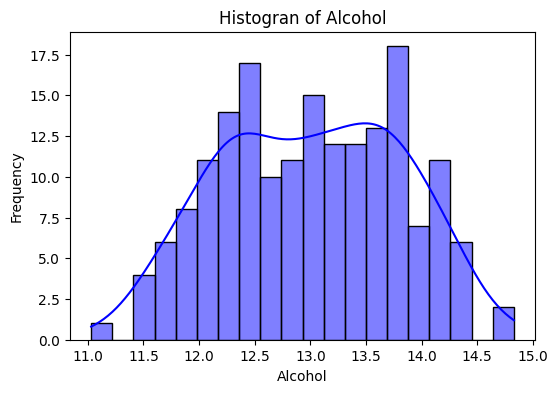

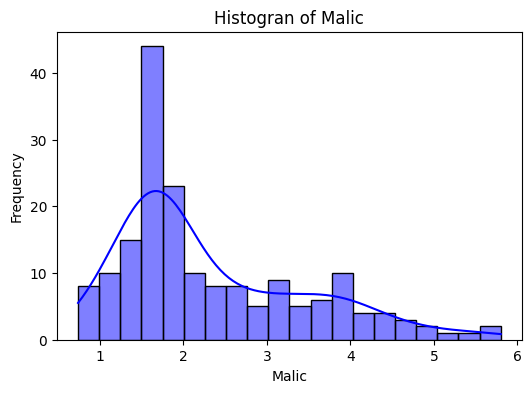

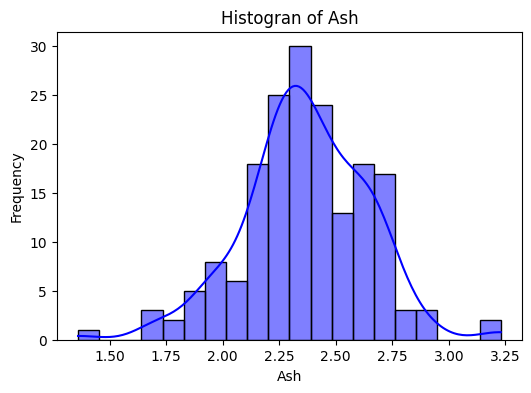

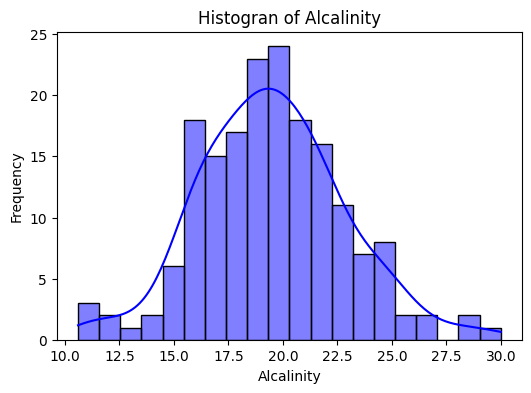

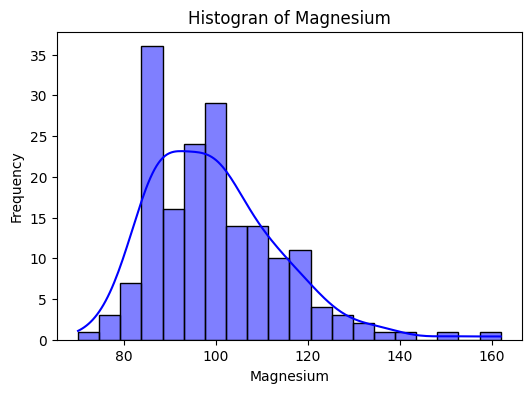

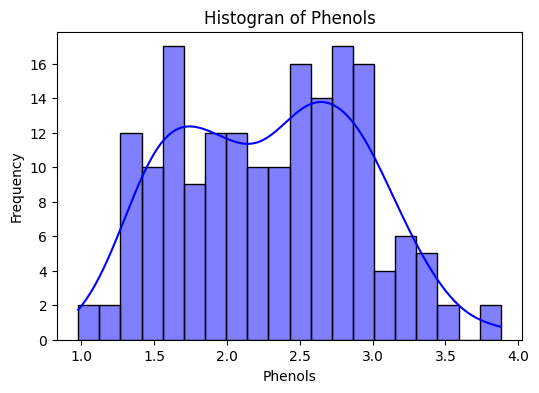

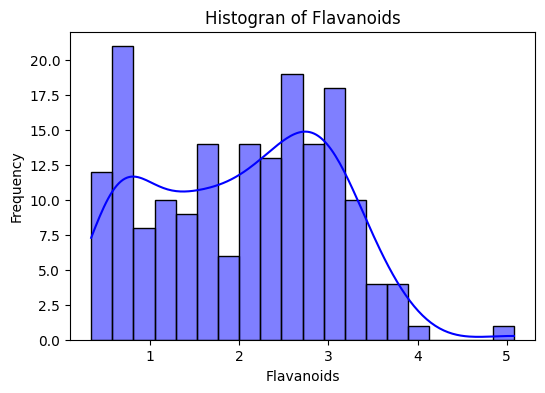

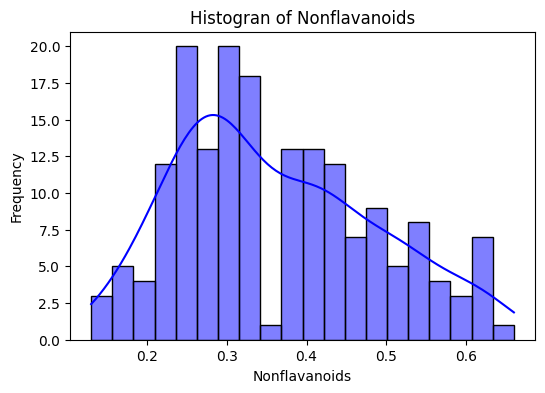

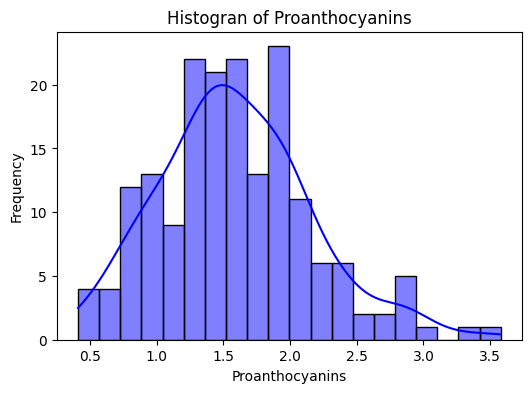

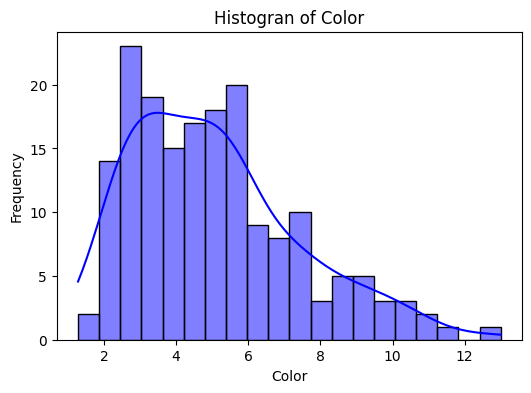

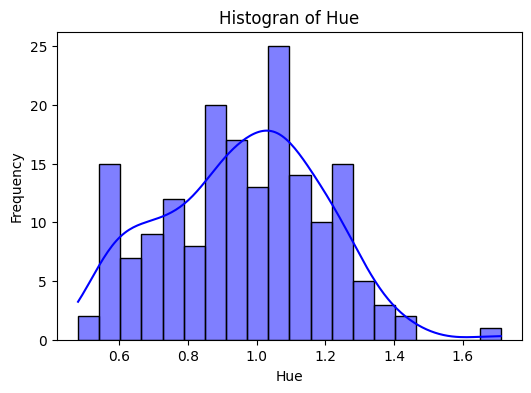

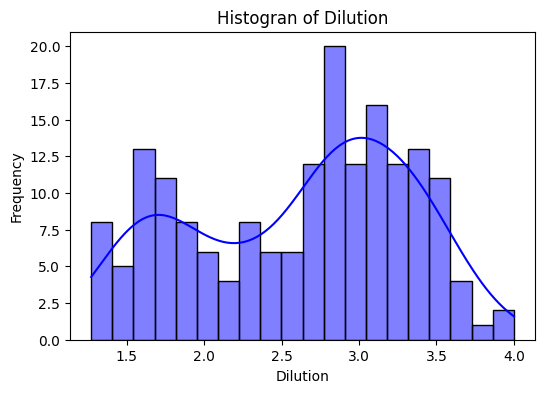

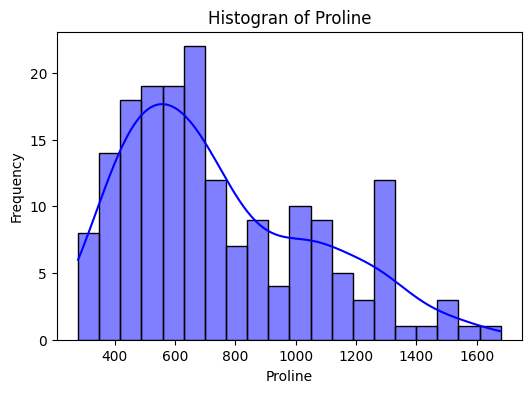

In [10]:
for col in df.drop(columns='Type'):
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=20, kde=True, color='blue', edgecolor='black')
    plt.title(f"Histogran of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

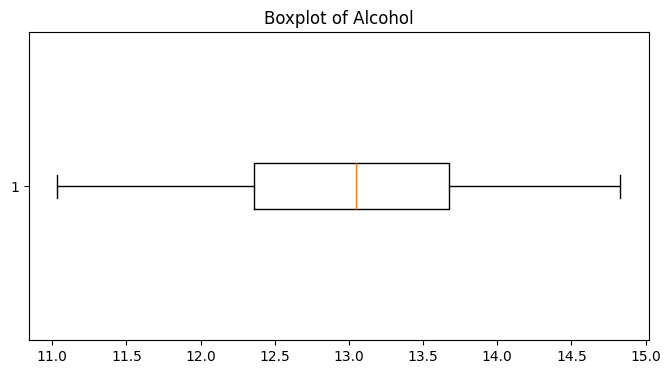

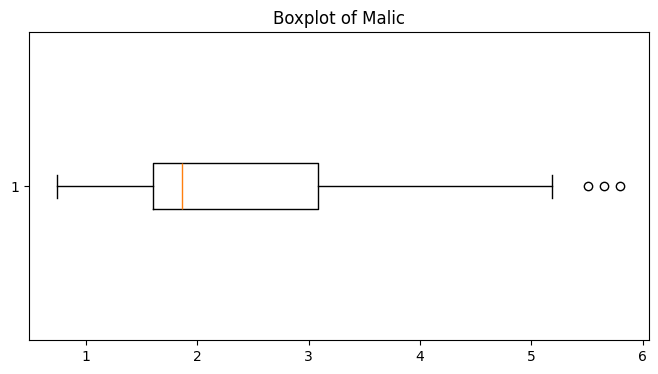

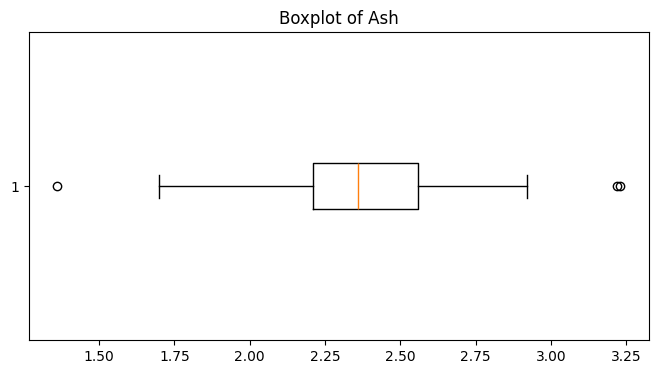

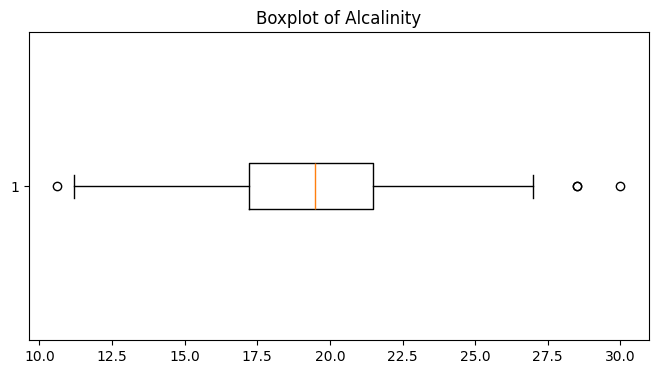

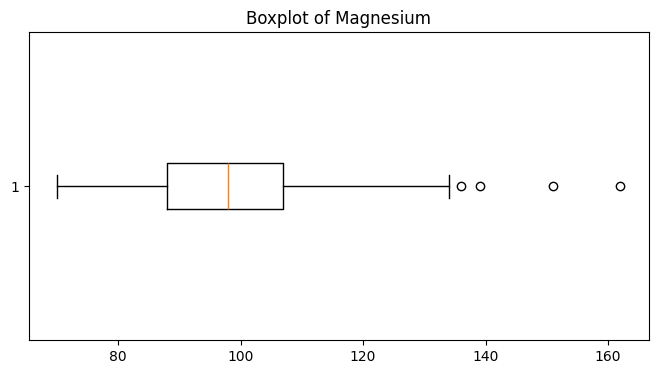

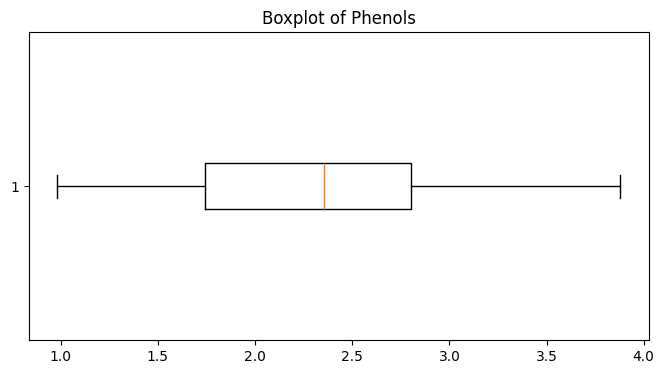

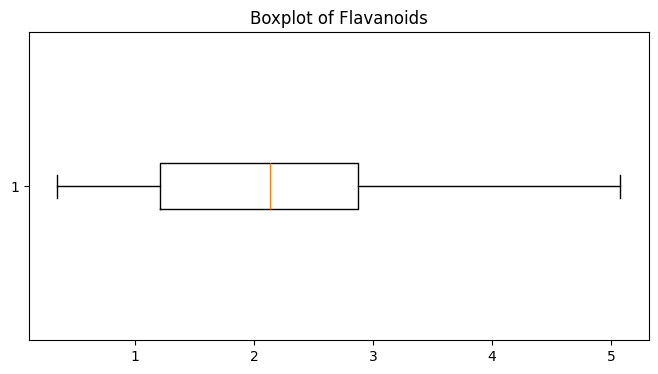

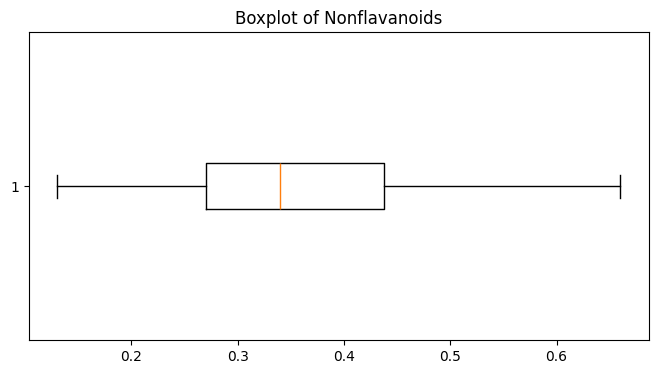

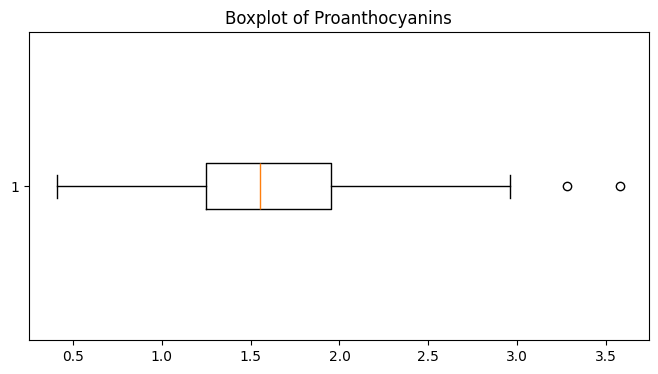

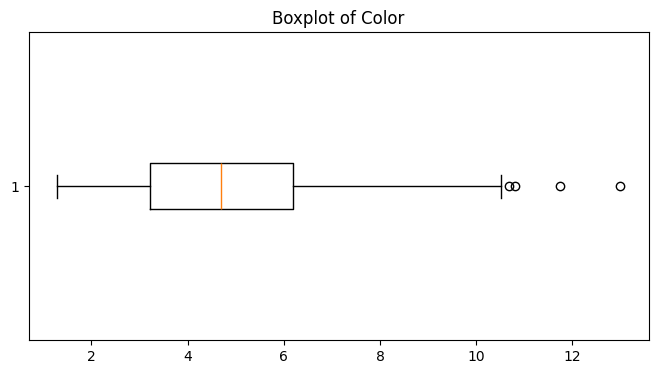

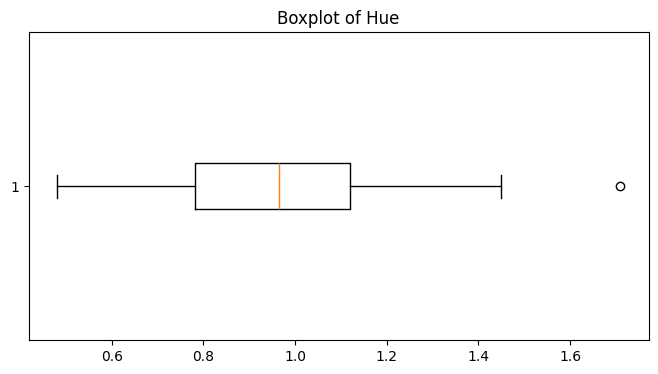

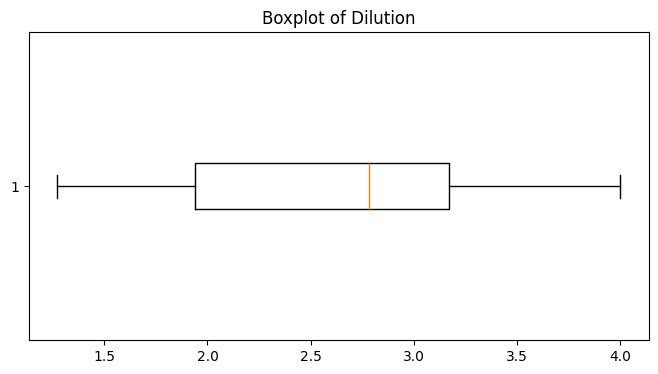

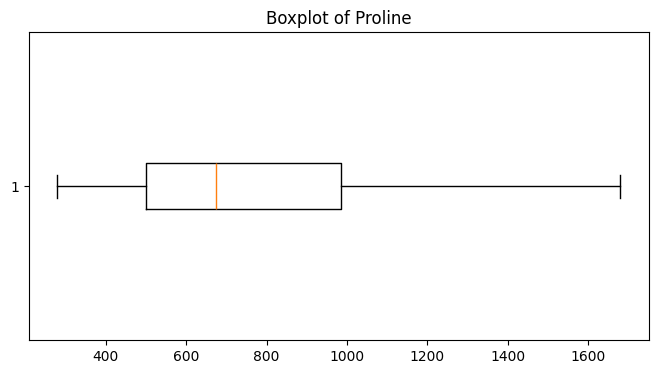

In [11]:
for col in df.drop(columns='Type'):
    plt.figure(figsize=(8,4))
    plt.boxplot(df[col], vert=False)
    plt.title(f"Boxplot of {col}")
    plt.show()

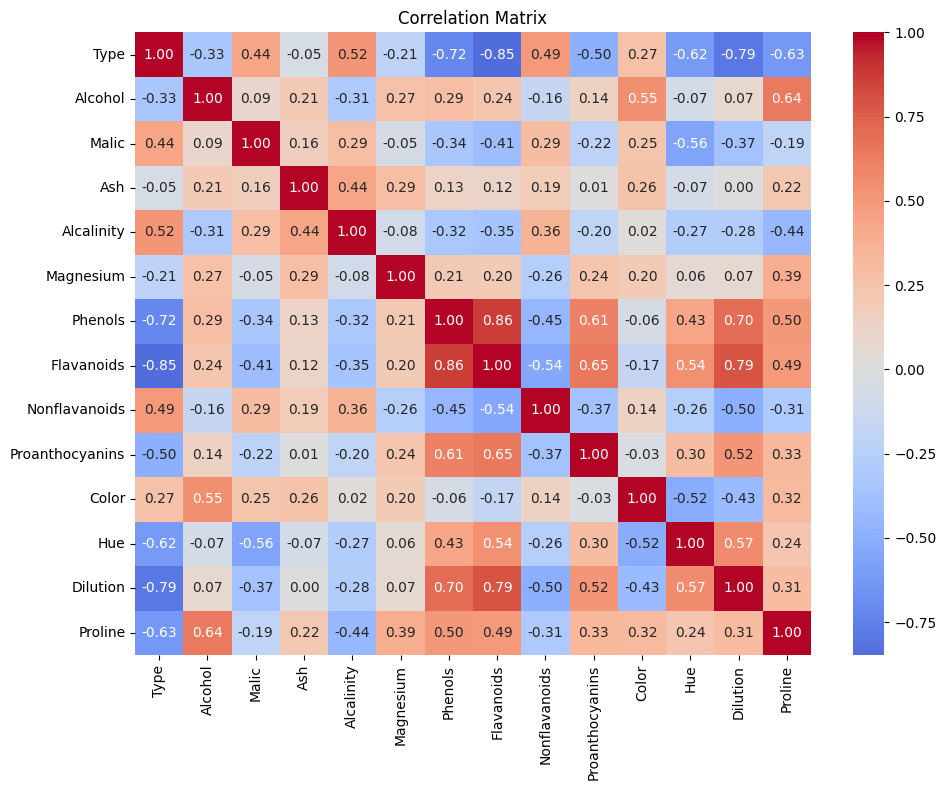

In [12]:
plt.figure(figsize=(10,8))
sns.heatmap(
    df.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## Task 2: Dimensionality Reduction with PCA:
1.	Standardize the features to ensure they have a mean of 0 and a standard deviation of Implement PCA to reduce the dimensionality of the dataset.
2.	Determine the optimal number of principal components using techniques like scree plot or cumulative explained variance.
3.	Transform the original dataset into the principal components.

In [13]:
X = df.drop(columns='Type')
y = df['Type']
X.shape, y.shape

((178, 13), (178,))

In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Mean of standardized features:")
print(X_scaled.mean(axis=0))
print("\nStandard deviation:")
print(X_scaled.std(axis=0))

Mean of standardized features:
[-8.38280756e-16 -1.19754394e-16 -8.37033314e-16 -3.99181312e-17
 -3.99181312e-17  0.00000000e+00 -3.99181312e-16  3.59263181e-16
 -1.19754394e-16  2.49488320e-17  1.99590656e-16  3.19345050e-16
 -1.59672525e-16]

Standard deviation:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [15]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
print("Original shape:", X_scaled.shape)
print("PCA shape:", X_pca.shape)

Original shape: (178, 13)
PCA shape: (178, 13)


In [16]:
explained_variance = pca.explained_variance_ratio_
for i, variance in enumerate(explained_variance, start=1):
    print(f"PC{i}:{variance:.4f}")

PC1:0.3620
PC2:0.1921
PC3:0.1112
PC4:0.0707
PC5:0.0656
PC6:0.0494
PC7:0.0424
PC8:0.0268
PC9:0.0222
PC10:0.0193
PC11:0.0174
PC12:0.0130
PC13:0.0080


In [17]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
for i , variance in enumerate(cumulative_variance, start=1):
    print(f"PC{i}: {variance:.4f}")

PC1: 0.3620
PC2: 0.5541
PC3: 0.6653
PC4: 0.7360
PC5: 0.8016
PC6: 0.8510
PC7: 0.8934
PC8: 0.9202
PC9: 0.9424
PC10: 0.9617
PC11: 0.9791
PC12: 0.9920
PC13: 1.0000


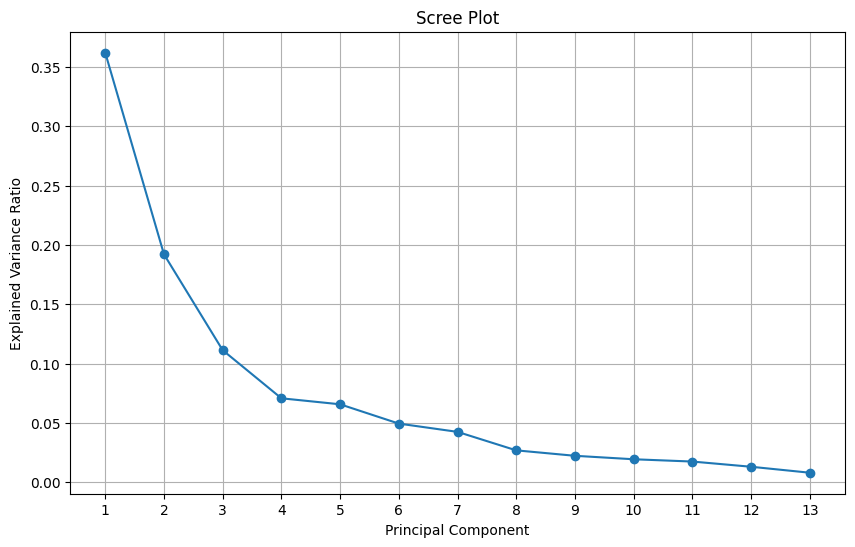

In [18]:
plt.figure(figsize=(10,6))
plt.plot(
    range(1, len(explained_variance) +1),
    explained_variance,
    marker='o'
)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.xticks(range(1, 14))
plt.grid(True)
plt.show()

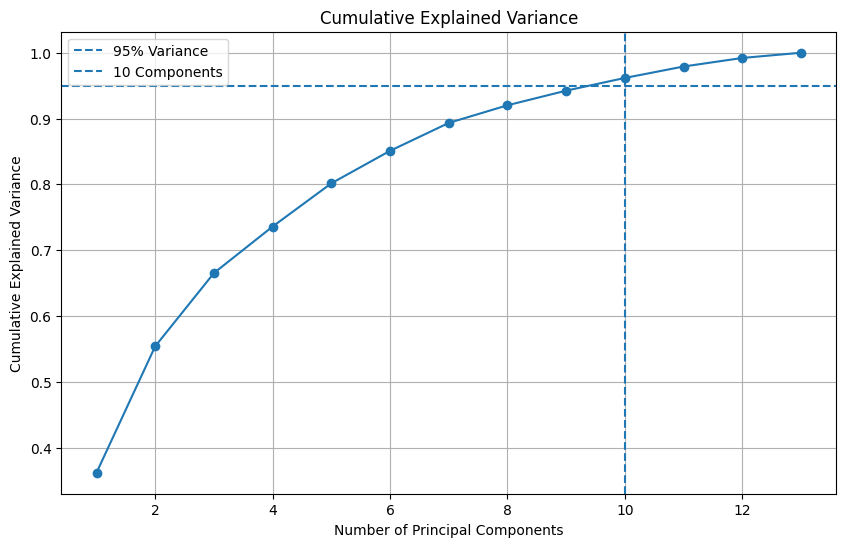

In [19]:
plt.figure(figsize=(10, 6))
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)
plt.axhline(
    y=0.95,
    linestyle="--",
    label="95% Variance"
)
plt.axvline(
    x=10,
    linestyle="--",
    label="10 Components"
)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.legend()
plt.grid(True)
plt.show()

In [20]:
pca_10 = PCA(n_components=10)
X_pca_10 = pca_10.fit_transform(X_scaled)
print("Original feature shape:", X_scaled.shape)
print("PCA feature shape:", X_pca_10.shape)

Original feature shape: (178, 13)
PCA feature shape: (178, 10)


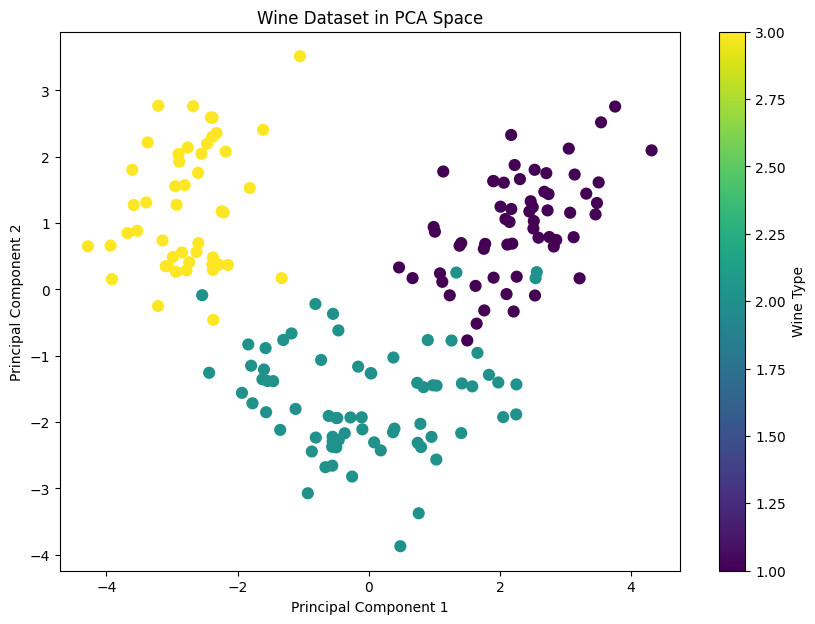

In [21]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    X_pca_10[:, 0],
    X_pca_10[:, 1],
    c=y,
    cmap="viridis",
    s=60
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Wine Dataset in PCA Space")
plt.colorbar(scatter, label="Wine Type")
plt.show()

In [22]:
k_values = range(2, 9)
silhouette_scores = []
db_scores = []
for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    labels = kmeans.fit_predict(X_scaled)
    silhouette_scores.append(
        silhouette_score(X_scaled, labels)
    )
    db_scores.append(
        davies_bouldin_score(X_scaled, labels)
    )

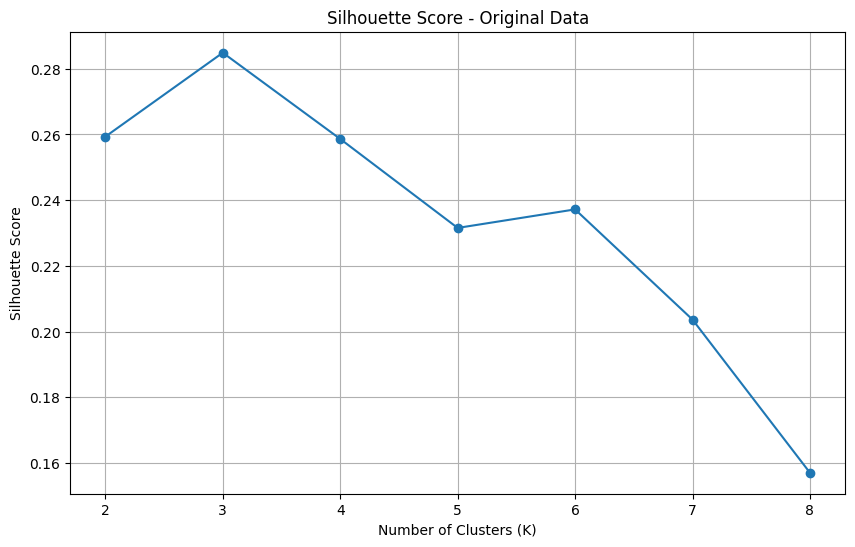

In [23]:
plt.figure(figsize=(10, 6))
plt.plot(
    k_values,
    silhouette_scores,
    marker="o"
)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score - Original Data")
plt.xticks(k_values)
plt.grid(True)
plt.show()

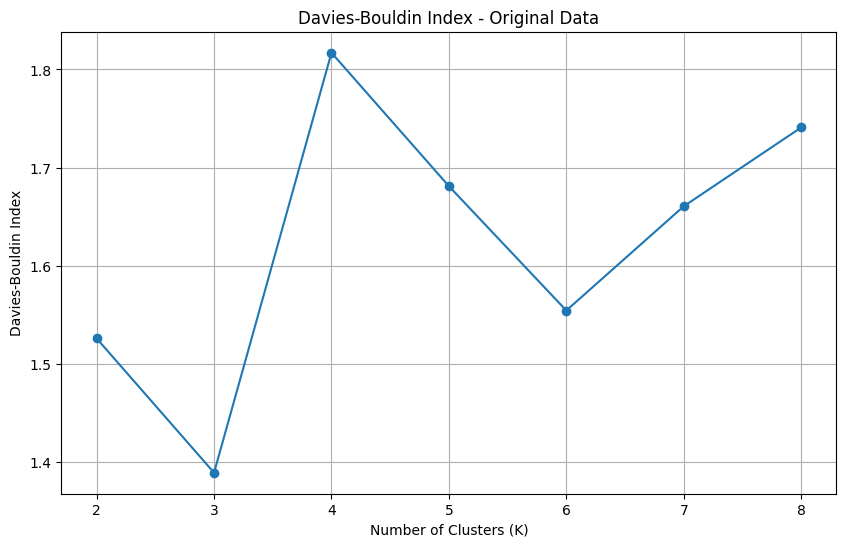

In [24]:
plt.figure(figsize=(10, 6))
plt.plot(
    k_values,
    db_scores,
    marker="o"
)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Davies-Bouldin Index")
plt.title("Davies-Bouldin Index - Original Data")
plt.xticks(k_values)
plt.grid(True)
plt.show()

## Task 3: Clustering with Original Data:
1.	Apply a clustering algorithm (e.g., K-means) to the original dataset.
2.	Visualize the clustering results using appropriate plots.
3.	Evaluate the clustering performance using metrics such as silhouette score or Davies–Bouldin index.

K-Means clustering on standardized original features

In [25]:
kmeans_original = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=20
)
clusters_original = kmeans_original.fit_predict(X_scaled)
df["Original_Cluster"] = clusters_original

In [26]:
sil_original = silhouette_score(
    X_scaled,
    clusters_original
)
db_original = davies_bouldin_score(
    X_scaled,
    clusters_original
)
print("Original Data")
print("-----------------------")
print("Silhouette Score:", round(sil_original, 4))
print("Davies-Bouldin Index:", round(db_original, 4))

Original Data
-----------------------
Silhouette Score: 0.2849
Davies-Bouldin Index: 1.3892


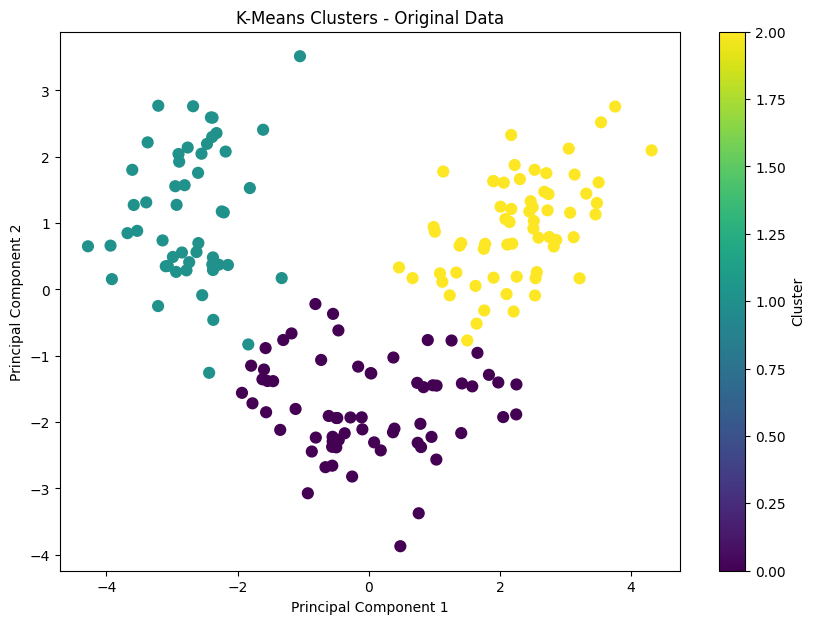

In [27]:
plt.figure(figsize=(10, 7))
plt.scatter(
    X_pca_10[:, 0],
    X_pca_10[:, 1],
    c=clusters_original,
    cmap="viridis",
    s=60
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters - Original Data")
plt.colorbar(label="Cluster")
plt.show()

## Task 4: Clustering with PCA Data:
1.	Apply the same clustering algorithm to the PCA-transformed dataset.
2.	Visualize the clustering results obtained from PCA-transformed data.
3.	Compare the clustering results from PCA-transformed data with those from the original dataset.

In [28]:
kmeans_pca = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=20
)
clusters_pca = kmeans_pca.fit_predict(X_pca_10)

In [29]:
sil_pca = silhouette_score(
    X_pca_10,
    clusters_pca
)
db_pca = davies_bouldin_score(
    X_pca_10,
    clusters_pca
)
print("PCA Data")
print("-----------------------")
print("Silhouette Score:", round(sil_pca, 4))
print("Davies-Bouldin Index:", round(db_pca, 4))

PCA Data
-----------------------
Silhouette Score: 0.2987
Davies-Bouldin Index: 1.3363


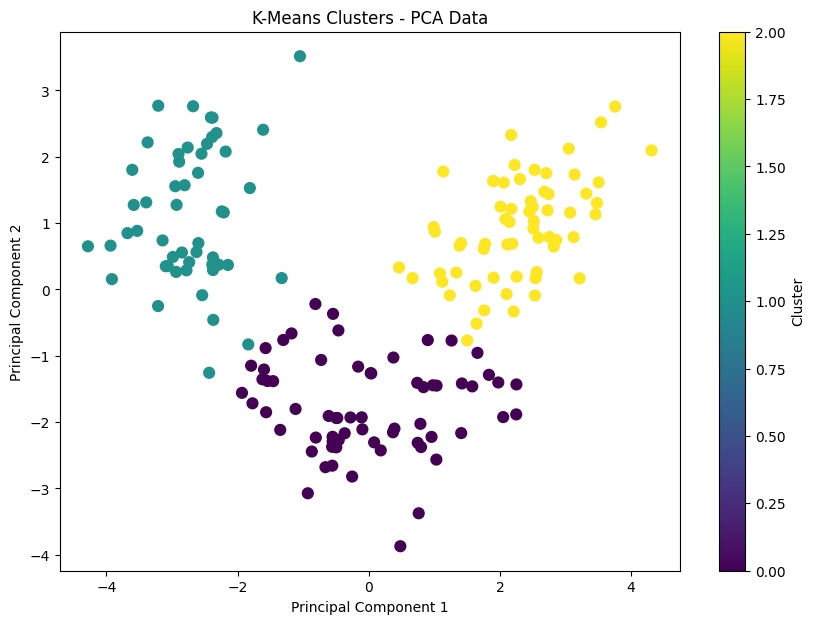

In [30]:
plt.figure(figsize=(10, 7))
plt.scatter(
    X_pca_10[:, 0],
    X_pca_10[:, 1],
    c=clusters_pca,
    cmap="viridis",
    s=60
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters - PCA Data")
plt.colorbar(label="Cluster")
plt.show()

## Task 5: Comparison and Analysis:
1.	Compare the clustering results obtained from the original dataset and PCA-transformed data.
2.	Discuss any similarities or differences observed in the clustering results.
3.	Reflect on the impact of dimensionality reduction on clustering performance.
4.	Analyze the trade-offs between using PCA and clustering directly on the original dataset.

In [31]:
comparison = pd.DataFrame({
    "Method": [
        "Original Standardized Data",
        "PCA Data"
    ],
    "Features Used": [
        13,
        10
    ],
    "Variance Retained": [
        100,
        pca_10.explained_variance_ratio_.sum() * 100
    ],
    "Silhouette Score": [
        sil_original,
        sil_pca
    ],
    "Davies-Bouldin Index": [
        db_original,
        db_pca
    ]
})
comparison

,Method,Features Used,Variance Retained,Silhouette Score,Davies-Bouldin Index
0,Original Standardized Data,13,100.000000,0.284859,1.389188
1,PCA Data,10,96.169717,0.298675,1.336326


In [32]:
ari_clusters = adjusted_rand_score(
    clusters_original,
    clusters_pca
)
print("Adjusted Rand Index between Original and PCA clusters:",
      round(ari_clusters, 4))

Adjusted Rand Index between Original and PCA clusters: 1.0


In [33]:
ari_original = adjusted_rand_score(
    y,
    clusters_original
)
ari_pca = adjusted_rand_score(
    y,
    clusters_pca
)
print("ARI - Original Data:", round(ari_original, 4))
print("ARI - PCA Data:", round(ari_pca, 4))

ARI - Original Data: 0.8975
ARI - PCA Data: 0.8975


In [34]:
cluster_comparison = pd.crosstab(
    df["Type"],
    clusters_original,
    rownames=["Actual Type"],
    colnames=["Cluster"]
)
cluster_comparison

Cluster,0,1,2
Actual Type,,,
1,0,0,59
2,65,3,3
3,0,48,0


### Impact of Dimensionality Reduction
PCA reduced the number of features from 13 to 10 while still keeping around 96.17% of the total variance. After applying K-Means, the PCA data gave a slightly better silhouette score and a lower Davies-Bouldin score compared to the standardized original data. This shows that PCA helped simplify the data without losing the important clustering structure.
m

### Trade-offs Between PCA and Original Data

Clustering directly on the standardized original features is easier to interpret because each feature has its original meaning. However, PCA reduces the number of features and removes some redundancy, which can make clustering more efficient and sometimes improve performance. The main drawback is that principal components are harder to interpret because they combine multiple original features.


## Task 6: Conclusion and Insights
1.	Summarize the key findings and insights from the assignment.
2.	Discuss the practical implications of using PCA and clustering in data analysis.
3.	Provide recommendations for when to use each technique based on the analysis conducted.

### Conclusion and Insights

Overall, PCA worked well for this dataset by reducing the number of features while preserving most of the important information. K-Means produced three meaningful clusters, and the PCA-based clustering performed slightly better than clustering on the standardized original data. This shows that PCA can be useful when features are correlated or when we want to simplify the dataset without significantly affecting the clustering results.

### Practical Implications

PCA is useful when a dataset has many features, strong correlations, or when visualization and computational efficiency are important. However, clustering directly on the original standardized features can be better when keeping the original feature meanings is important. In this analysis, PCA was a good choice because it reduced the dimensionality while maintaining the overall clustering structure.
